In [2]:
!pip -q install pandas matplotlib folium

In [4]:
import os
import json
from pathlib import Path
from datetime import datetime

import pandas as pd
import matplotlib.pyplot as plt
import folium

import db                                  
from trip_management import Trip          
from user_classes import Rider, Driver, TripState
from map_integration import MapService, MockMapService

if os.getenv("ORS_API_KEY"):
    map_service = MapService()          
    print("MapService: OpenRouteService (live)")
else:
    map_service = MockMapService()  
    print("MapService: MOCK")


MapService: MOCK


In [6]:
db.init_db()
print("DB path:", Path(db.DB_PATH).resolve())

TRIPSTATE_TO_DB = {
    TripState.REQUESTED: "requested",
    TripState.ACCEPTED: "accept",
    TripState.DECLINED: "declined",
    TripState.IN_PROGRESS: "in progress",  
    TripState.COMPLETED: "completed",
    TripState.CANCELLED: "cancelled",
}

DB path: /Users/mernafady/Desktop/uber_lyft_sim/app.db


In [8]:
from typing import Optional, Tuple, Dict

def _parse_latlng(s: str) -> Optional[Tuple[float, float]]:
    if not isinstance(s, str) or "," not in s:
        return None
    try:
        a, b = s.split(",", 1)
        return float(a.strip()), float(b.strip())
    except Exception:
        return None

def get_route_info(pickup: str, destination: str) -> Dict[str, float]:
    """
    Returns {'distance_km': float, 'duration_min': float}
    Uses:
      - direct coords if pickup/destination are 'lat,lng'
      - or geocode + route via MapService/MockMapService
    """
    p = _parse_latlng(pickup)
    d = _parse_latlng(destination)

    if p and d:
        data = map_service.get_route(p, d)
        if not data:
            raise RuntimeError("Routing failed for provided coordinates.")
        return {"distance_km": float(data["distance_km"]), "duration_min": float(data["duration_min"])}

    data = map_service.calculate_trip_route(pickup, destination)
    if not data:
        raise RuntimeError("Routing failed (geocode + route).")
    return {"distance_km": float(data["distance_km"]), "duration_min": float(data["duration_min"])}


In [28]:
# TripController 
from contextlib import contextmanager

@contextmanager
def _conn():
    with db.connect() as con:
        yield con

def _safe_distance_km(pickup: str, destination: str) -> int:
    info = get_route_info(pickup, destination)
    return max(1, int(round(info["distance_km"])))

def _slug(s: str) -> str:
    return "".join(ch for ch in s.lower().strip().replace(" ", "_") if ch.isalnum() or ch in "._-")

class TripController:
    """
    Manages:
    - Riders/Drivers (from user_classes)
    - Trip objects (from trip_management)
    - Lifecycle updates (accept, start, complete, cancel)
    - Persists data to SQLite using db.py
    """
    def __init__(self):
        self.live_trips = {}       
        self.riders = {}          
        self.drivers = {}          

    def _get_or_create_user(self, name: str, role: str, rating: str):
        """Create a DB user only if they don't already exist."""
        rows = db.get_all_users(limit=9999)
        for r in rows:
            if r[1] == name and r[3] == role:
                return r[0]
        return db.create_user(name, rating, role)

    def new_rider(self, name="Rider A", email=None, phone=None, rating="4.9"):
        """Create a Rider(user_id, name, email, phone)"""
        self._get_or_create_user(name, role="rider", rating=rating)

        uid = f"rider_{_slug(name)}"
        email = email or f"{_slug(name)}@example.com"
        phone = phone or "000-000-0000"

        rider = Rider(uid, name, email, phone)
        self.riders[name] = rider
        return name

    def new_driver(self, name="Driver 1", email=None, phone=None,
                   vehicle_type="Sedan", license_plate="TEST123", rating="4.8"):
        """Create a Driver(user_id, name, email, phone, vehicle_type, license_plate)"""
        self._get_or_create_user(name, role="driver", rating=rating)

        uid = f"driver_{_slug(name)}"
        email = email or f"{_slug(name)}@example.com"
        phone = phone or "000-000-0000"

        driver = Driver(uid, name, email, phone, vehicle_type, license_plate)
        self.drivers[name] = driver
        return name

    def accept(self, team_trip_id: int, driver_name="Driver 1"):
        trip, db_id = self.live_trips[team_trip_id]

        drv = self.drivers.get(driver_name)
        if drv is None:
            uid = f"driver_{_slug(driver_name)}"
            drv = Driver(uid, driver_name, f"{_slug(driver_name)}@example.com",
                         "000-000-0000", "Sedan", "TEST123")
            self._get_or_create_user(driver_name, role="driver", rating="4.8")
            self.drivers[driver_name] = drv

        trip.accept(drv)
        db.update_trip_status(db_id, TRIPSTATE_TO_DB[trip.state])

    def start(self, team_trip_id: int):
        trip, db_id = self.live_trips[team_trip_id]
        trip.start()
        db.update_trip_status(db_id, TRIPSTATE_TO_DB[trip.state])

    def complete(self, team_trip_id: int):
        trip, db_id = self.live_trips[team_trip_id]
        trip.complete()
        db.update_trip_status(db_id, TRIPSTATE_TO_DB[trip.state])

    def decline(self, team_trip_id: int):
        trip, db_id = self.live_trips[team_trip_id]
        trip.decline()
        db.update_trip_status(db_id, TRIPSTATE_TO_DB[trip.state])

    def cancel(self, team_trip_id: int):
        """Cancel trip (Trip class may not have cancel())"""
        _trip, db_id = self.live_trips[team_trip_id]
        db.update_trip_status(db_id, "cancelled")

    def trips_df(self, limit=1000) -> pd.DataFrame:
        rows = db.list_trips(limit=limit)
        df = pd.DataFrame(rows, columns=[
            "id","created_at","pickup","destination","strategy","fare","state","distance"
        ])
        if not df.empty:
            df["created_at"] = pd.to_datetime(df["created_at"])
        return df


In [30]:
# Cell 4B: Override create_trip to satisfy NOT NULL distance 
def _tripcontroller_create_trip(self, pickup: str, destination: str,
                                rider_name="Rider A", strategy="Standard") -> tuple[int, int]:
    """
    Replaces TripController.create_trip with a version that inserts distance
    directly into the SQL so NOT NULL constraint is satisfied.
    """

    # 1) Ensure rider exists
    rider = self.riders.get(rider_name)
    if rider is None:
        uid = f"rider_{_slug(rider_name)}"
        rider = Rider(uid, rider_name, f"{_slug(rider_name)}@example.com", "000-000-0000")
        self._get_or_create_user(rider_name, role="rider", rating="5.0")
        self.riders[rider_name] = rider

    # 2) Create in-memory Trip
    trip = Trip(
        pickup=pickup,
        destination=destination,
        rider=rider,
        strategy_name=strategy
    )

    # 3) Route + fare
    route = get_route_info(pickup, destination)
    trip.set_route_info(
        distance_km=route["distance_km"],
        duration_min=route["duration_min"]
    )
    distance_int_km = max(1, int(round(route["distance_km"])))

    # 4) Insert directly into DB with distance
    with _conn() as con:
        cur = con.cursor()
        cur.execute(
            """
            INSERT INTO trips (pickup, destination, strategy, fare, state, distance)
            VALUES (?, ?, ?, ?, 'requested', ?)
            """,
            (pickup, destination, strategy.lower(), float(trip.base_fare), distance_int_km)
        )
        db_trip_id = cur.lastrowid

    # 5) Save mapping
    self.live_trips[trip.trip_id] = (trip, db_trip_id)
    return trip.trip_id, db_trip_id

# Apply override
TripController.create_trip = _tripcontroller_create_trip

In [68]:
# Demo run
import datetime as dt

# 0) Clear old trips from the DB so we don't double-count
with db.connect() as con:
    con.execute("DELETE FROM trips")

# 1) New controller, rider, and driver
ctl = TripController()

ctl.new_rider(
    name="Rider A",
    email="rider.a@example.com",
    phone="555-000-0001",
    rating="4.9"
)

ctl.new_driver(
    name="Driver 1",
    email="driver.1@example.com",
    phone="555-000-0002",
    vehicle_type="Sedan",
    license_plate="7ABC123",
    rating="4.8"
)

# offset = how many days ago (0 = today, 1 = yesterday, etc.)
trip_scenarios = [
    {"offset": 4, "strategy": "Standard", "final_state": "completed"},
    {"offset": 4, "strategy": "Premium",  "final_state": "completed"},
    {"offset": 3, "strategy": "Surge",    "final_state": "completed"},
    {"offset": 3, "strategy": "Standard", "final_state": "cancelled"},
    {"offset": 2, "strategy": "Premium",  "final_state": "completed"},
    {"offset": 2, "strategy": "Standard", "final_state": "requested"},  
    {"offset": 1, "strategy": "Surge",    "final_state": "completed"},
    {"offset": 1, "strategy": "Standard", "final_state": "completed"},
    {"offset": 0, "strategy": "Premium",  "final_state": "completed"},
    {"offset": 0, "strategy": "Surge",    "final_state": "cancelled"},
]

today = dt.date.today()
created_trip_ids = []    

for scenario in trip_scenarios:
    offset = scenario["offset"]
    strategy = scenario["strategy"]
    final_state = scenario["final_state"]

    # 3) Create the trip (TripController handles distance + fare + DB insert)
    team_id, db_id = ctl.create_trip(
        pickup="34.101,-118.326",          # Hollywood coords
        destination="33.941,-118.408",     # LAX coords
        rider_name="Rider A",
        strategy=strategy
    )

    # 4) Apply state transitions for revenue stats
    #    (Revenue by day only counts completed trips)
    if final_state in ("completed", "cancelled", "requested"):
        if final_state != "requested":
            ctl.accept(team_id, driver_name="Driver 1")

        if final_state == "completed":
            ctl.start(team_id)
            ctl.complete(team_id)
        elif final_state == "cancelled":
            ctl.cancel(team_id)

    # 5) Backdate created_at so trips are spread across days
    trip_date = today - dt.timedelta(days=offset)
    created_at_str = f"{trip_date} 10:00:00" 

    with db.connect() as con:
        con.execute(
            "UPDATE trips SET created_at = ? WHERE id = ?",
            (created_at_str, db_id)
        )

    created_trip_ids.append(db_id)

print("Created DB trip IDs:", created_trip_ids)

df = ctl.trips_df()
df["created_at"] = pd.to_datetime(df["created_at"])
df["date"] = df["created_at"].dt.date
df


Created DB trip IDs: [28, 29, 30, 31, 32, 33, 34, 35, 36, 37]


,id,created_at,pickup,destination,strategy,fare,state,distance,date
0,36,2025-11-16 10:00:00,"34.101,-118.326","33.941,-118.408",premium,69.858797,completed,20,2025-11-16
1,37,2025-11-16 10:00:00,"34.101,-118.326","33.941,-118.408",surge,74.547501,cancelled,20,2025-11-16
2,34,2025-11-15 10:00:00,"34.101,-118.326","33.941,-118.408",surge,74.547501,completed,20,2025-11-15
3,35,2025-11-15 10:00:00,"34.101,-118.326","33.941,-118.408",standard,41.415278,completed,20,2025-11-15
4,32,2025-11-14 10:00:00,"34.101,-118.326","33.941,-118.408",premium,69.858797,completed,20,2025-11-14
5,33,2025-11-14 10:00:00,"34.101,-118.326","33.941,-118.408",standard,41.415278,requested,20,2025-11-14
6,30,2025-11-13 10:00:00,"34.101,-118.326","33.941,-118.408",surge,74.547501,completed,20,2025-11-13
7,31,2025-11-13 10:00:00,"34.101,-118.326","33.941,-118.408",standard,41.415278,cancelled,20,2025-11-13
8,28,2025-11-12 10:00:00,"34.101,-118.326","33.941,-118.408",standard,41.415278,completed,20,2025-11-12
9,29,2025-11-12 10:00:00,"34.101,-118.326","33.941,-118.408",premium,69.858797,completed,20,2025-11-12


In [70]:
df = ctl.trips_df()
if not df.empty:
    df["date"] = df["created_at"].dt.date
    df["fare"] = pd.to_numeric(df["fare"], errors="coerce").fillna(0.0)
    df["distance"] = pd.to_numeric(df["distance"], errors="coerce").fillna(0).astype(int)

df.head()

,id,created_at,pickup,destination,strategy,fare,state,distance,date
0,36,2025-11-16 10:00:00,"34.101,-118.326","33.941,-118.408",premium,69.858797,completed,20,2025-11-16
1,37,2025-11-16 10:00:00,"34.101,-118.326","33.941,-118.408",surge,74.547501,cancelled,20,2025-11-16
2,34,2025-11-15 10:00:00,"34.101,-118.326","33.941,-118.408",surge,74.547501,completed,20,2025-11-15
3,35,2025-11-15 10:00:00,"34.101,-118.326","33.941,-118.408",standard,41.415278,completed,20,2025-11-15
4,32,2025-11-14 10:00:00,"34.101,-118.326","33.941,-118.408",premium,69.858797,completed,20,2025-11-14


In [72]:
def kpis(df: pd.DataFrame) -> dict:
    if df.empty:
        return {"trips": 0, "completed": 0, "avg_fare": 0.0, "total_revenue": 0.0, "avg_distance_km": 0.0}
    return {
        "trips": int(len(df)),
        "completed": int((df["state"] == "completed").sum()),
        "avg_fare": round(df["fare"].mean(), 2),
        "total_revenue": round(df.loc[df["state"] == "completed", "fare"].sum(), 2),
        "avg_distance_km": round(df["distance"].mean(), 2),
    }

KPI = kpis(df)
KPI

{'trips': 10,
 'completed': 7,
 'avg_fare': 59.89,
 'total_revenue': 441.5,
 'avg_distance_km': 20.0}

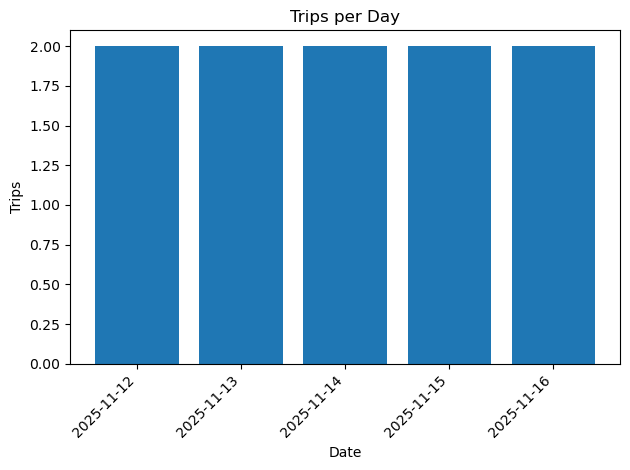

In [74]:
plt.figure()
plt.title("Trips per Day")
if df.empty:
    plt.text(0.5, 0.5, "No data", ha="center", va="center")
else:
    grouped = df.groupby("date").size()
    plt.bar(grouped.index.astype(str), grouped.values)
    plt.xlabel("Date"); plt.ylabel("Trips"); plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("trips_per_day.png")
plt.show()

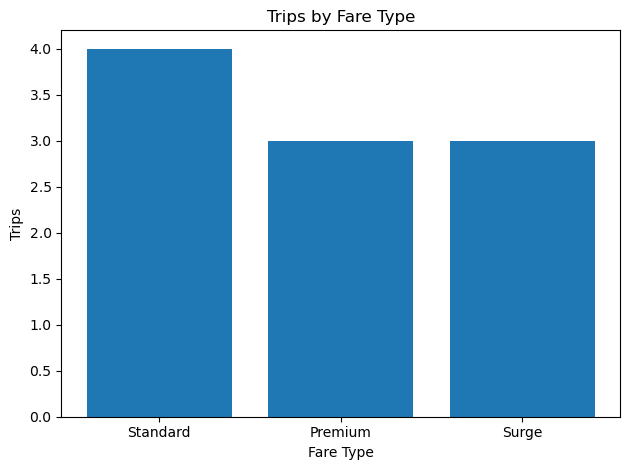

In [76]:
plt.figure()
plt.title("Trips by Fare Type")
if df.empty:
    plt.text(0.5, 0.5, "No data", ha="center", va="center")
else:
    counts = df["strategy"].str.title().value_counts()
    plt.bar(counts.index.astype(str), counts.values)
    plt.xlabel("Fare Type"); plt.ylabel("Trips")
plt.tight_layout()
plt.savefig("trips_by_strategy.png")
plt.show()

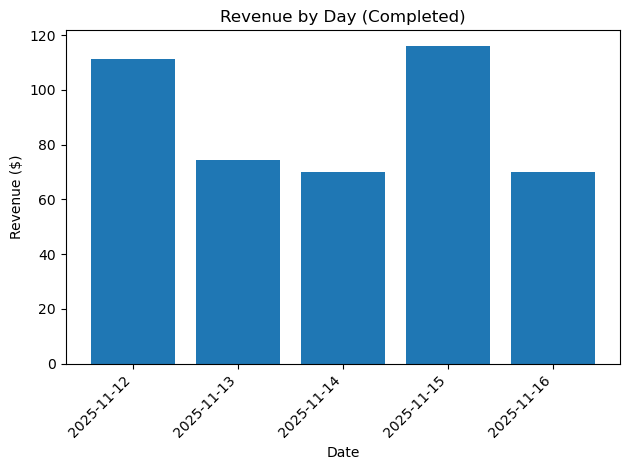

In [78]:
plt.figure()
plt.title("Revenue by Day (Completed)")
if df.empty:
    plt.text(0.5, 0.5, "No data", ha="center", va="center")
else:
    rev = df[df["state"]=="completed"].groupby("date")["fare"].sum()
    plt.bar(rev.index.astype(str), rev.values)
    plt.xlabel("Date"); plt.ylabel("Revenue ($)"); plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("revenue_by_day.png")
plt.show()

In [80]:
def build_trip_map(html_path="dashboard_map.html", center=(34.0522, -118.2437), zoom_start=11):
    m = folium.Map(location=center, zoom_start=zoom_start)
    if df.empty:
        m.save(html_path); return html_path

    def parse_latlng(s):
        if not isinstance(s, str) or "," not in s:
            return None
        try:
            a, b = s.split(",", 1)
            return float(a.strip()), float(b.strip())
        except:
            return None

    for _, r in df.iterrows():
        p = parse_latlng(r["pickup"]); d = parse_latlng(r["destination"])
        if not (p and d): 
            continue
        folium.PolyLine([p, d], tooltip=f"Trip {r['id']} ({r['strategy']})").add_to(m)
        folium.CircleMarker(p, radius=4, popup=f"Pickup {r['id']}").add_to(m)
        folium.CircleMarker(d, radius=4, popup=f"Dropoff {r['id']}").add_to(m)
    m.save(html_path)
    return html_path

build_trip_map("dashboard_map.html")

'dashboard_map.html'

In [82]:
from nbconvert import PythonExporter
import nbformat

nb_name = "trip_manager_dashboard.ipynb"
nb = nbformat.read(nb_name, as_version=4)
py, _ = PythonExporter().from_notebook_node(nb)
Path("trip_manager_dashboard.py").write_text(py, encoding="utf-8")
print("Exported → trip_manager_dashboard.py")

Exported → trip_manager_dashboard.py
